<a href="https://www.kaggle.com/code/gpreda/recovery-resilience-facility-used-by-france?scriptVersionId=259191338" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<center><h1>Recovery & Resilience facility used by France</h1></center>
<br><br>
<center><img src="https://upload.wikimedia.org/wikipedia/commons/4/4a/Flag_of_France_%282024%E2%80%93present%29.svg" width=400></img></center>

<br><br>
# Introduction

This dataset is about usage of Recovery & Resilience facility. 

More information about this facility of EU: https://commission.europa.eu/business-economy-euro/economic-recovery/recovery-and-resilience-facility_en

We will analyse the use of RRF by France.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/recovery-and-resilience-facility-rrf-uses/estat_gov_rrf_use_en.csv")

In [3]:
df.shape

(5472, 11)

In [4]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,DATAFLOW,LAST UPDATE,freq,na_item,fin_typ,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:GOV_RRF_USE(1.0),21/05/25 11:00:00,A,CAP,GRNT,MIO_EUR,AT,2020,78.81,NaN,NaN
1,ESTAT:GOV_RRF_USE(1.0),21/05/25 11:00:00,A,CAP,GRNT,MIO_EUR,AT,2021,127.75,NaN,NaN
2,ESTAT:GOV_RRF_USE(1.0),21/05/25 11:00:00,A,CAP,GRNT,MIO_EUR,AT,2022,523.05,NaN,NaN
3,ESTAT:GOV_RRF_USE(1.0),21/05/25 11:00:00,A,CAP,GRNT,MIO_EUR,AT,2023,778.43,NaN,NaN
4,ESTAT:GOV_RRF_USE(1.0),21/05/25 11:00:00,A,CAP,GRNT,MIO_EUR,AT,2024,293.29,NaN,NaN


# Total amount grouped by national acounts items


We will show the total (millions EUR) engaged by France between 2020 and 2024 by national accounts. The meaning of `na_item` is:

* CAP — Capital expenditure (all capital outlays).
* CUR — Current expenditure (wages, goods/services, subsidies, interest, etc.).
* TOTAL — Total expenditure = CUR + CAP.
* P51G — Gross fixed capital formation (investment in fixed assets like buildings, machinery).
* D9 — Capital transfers (e.g., investment grants, other one-off capital transfers).
* OTH — Other (a residual/“other” bucket; often for items not elsewhere classified).
* CAP_OTH — Other capital expenditure (capital items other than P.51g and D.9).

In [5]:
gr = df.loc[(df.unit=="MIO_EUR") & (df.geo=="FR") & (df.fin_typ=="TOTAL")].groupby("na_item")["OBS_VALUE"].sum().reset_index()

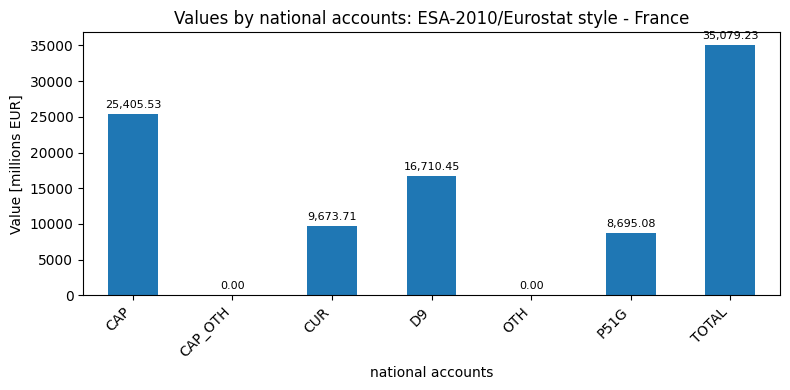

In [6]:
ax = gr.plot(kind="bar", x="na_item", y="OBS_VALUE", legend=False, figsize=(8,4))
ax.set_xlabel("national accounts")
ax.set_ylabel("Value [millions EUR]")
ax.set_title("Values by national accounts: ESA-2010/Eurostat style - France")
plt.xticks(rotation=45, ha="right")

# (Optional) annotate bars with values
for p in ax.patches:
    v = p.get_height()
    ax.annotate(f"{v:,.2f}", (p.get_x()+p.get_width()/2, v),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Total amount grouped by year

In [7]:
gr = df.loc[(df.unit=="MIO_EUR") & (df.geo=="FR") & (df.fin_typ=="TOTAL") & (df.na_item=="TOTAL")].groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()

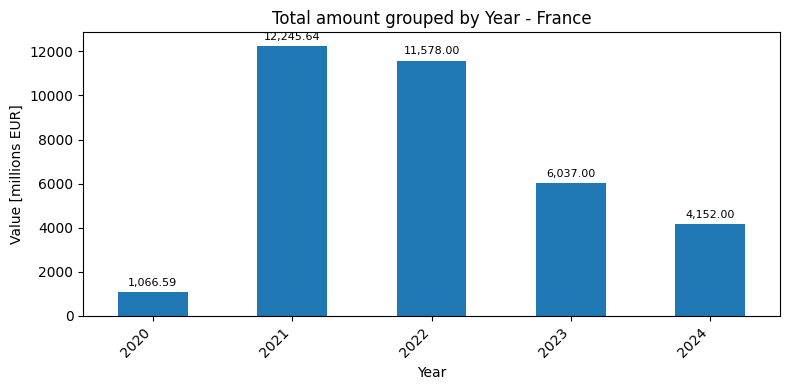

In [8]:
ax = gr.plot(kind="bar", x="TIME_PERIOD", y="OBS_VALUE", legend=False, figsize=(8,4))
ax.set_xlabel("Year")
ax.set_ylabel("Value [millions EUR]")
ax.set_title("Total amount grouped by Year - France")
plt.xticks(rotation=45, ha="right")

# (Optional) annotate bars with values
for p in ax.patches:
    v = p.get_height()
    ax.annotate(f"{v:,.2f}", (p.get_x()+p.get_width()/2, v),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Total amount grouped by year and national accounts items


It is important to understand the relationship between the  `na_item` types:

* CAP — Capital expenditure (all capital outlays).
* CUR — Current expenditure (wages, goods/services, subsidies, interest, etc.).
* TOTAL — Total expenditure = CUR + CAP.
* P51G — Gross fixed capital formation (investment in fixed assets like buildings, machinery).
* D9 — Capital transfers (e.g., investment grants, other one-off capital transfers).
* OTH — Other (a residual/“other” bucket; often for items not elsewhere classified).
* CAP_OTH — Other capital expenditure (capital items other than P.51g and D.9).

CAP, P51G, D9, CAP_OTH - are capital expenditures, total and on chapters.
CUR - are current expenditures
TOTAL is sum of capital expenditures (CAP) and current expenditures (CUR).

In [9]:
gr = df.loc[(df.unit=="MIO_EUR") &\
(df.geo=="FR") &\
(df.fin_typ!="TOTAL")].groupby(["na_item", "TIME_PERIOD"])["OBS_VALUE"].sum().reset_index()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


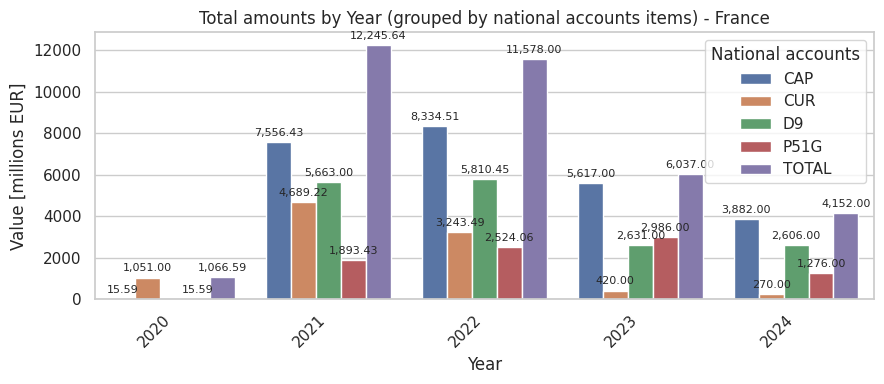

In [10]:
sns.set_theme(style="whitegrid")

# Order the x-axis nicely
order = sorted(gr["TIME_PERIOD"].unique())
gr["TIME_PERIOD"] = pd.Categorical(gr["TIME_PERIOD"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=gr,
    x="TIME_PERIOD", y="OBS_VALUE",
    hue="na_item", dodge=True, errorbar=None, ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Value [millions EUR]")
ax.set_title("Total amounts by Year (grouped by national accounts items) - France")
plt.xticks(rotation=45, ha="right")
ax.legend(title="National accounts", ncols=1, frameon=True)

# Annotate each bar
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:,.2f}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

# Total amount grouped by year and financing type

In [11]:
gr = df.loc[(df.unit=="MIO_EUR") &\
(df.geo=="FR") &\
(df.fin_typ!="TOTAL") &\
(df.na_item=="TOTAL")].groupby(["fin_typ", "TIME_PERIOD"])["OBS_VALUE"].sum().reset_index()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


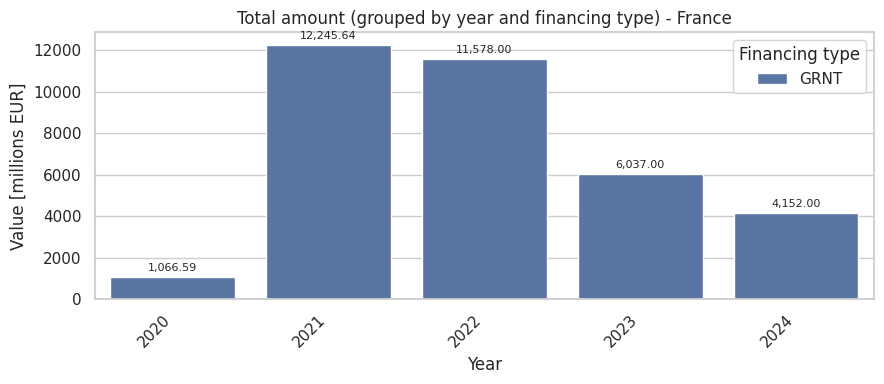

In [12]:
sns.set_theme(style="whitegrid")

# Order the x-axis nicely
order = sorted(gr["TIME_PERIOD"].unique())
gr["TIME_PERIOD"] = pd.Categorical(gr["TIME_PERIOD"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=gr,
    x="TIME_PERIOD", y="OBS_VALUE",
    hue="fin_typ", dodge=True, errorbar=None, ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Value [millions EUR]")
ax.set_title("Total amount (grouped by year and financing type) - France")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Financing type", ncols=1, frameon=True)

# Annotate each bar
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:,.2f}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

Let's check the same, but expressed as percent from GDP.

In [13]:
gr = df.loc[(df.unit=="PC_GDP") &\
(df.geo=="FR") &\
(df.fin_typ!="TOTAL") &\
(df.na_item=="TOTAL")].groupby(["fin_typ", "TIME_PERIOD"])["OBS_VALUE"].sum().reset_index()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


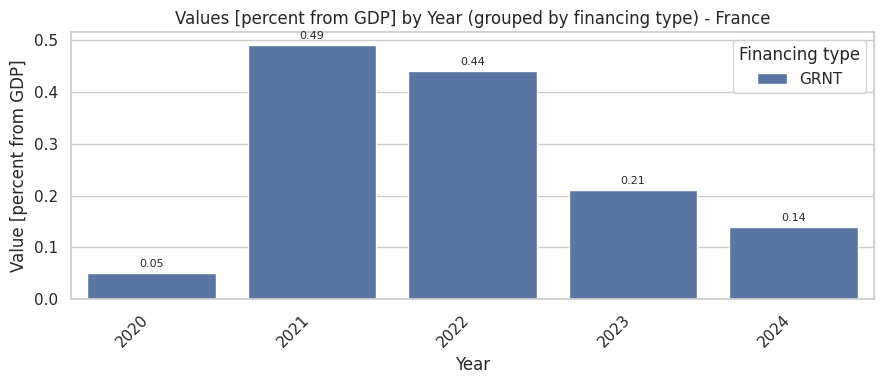

In [14]:
# Order the x-axis nicely
order = sorted(gr["TIME_PERIOD"].unique())
gr["TIME_PERIOD"] = pd.Categorical(gr["TIME_PERIOD"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=gr,
    x="TIME_PERIOD", y="OBS_VALUE",
    hue="fin_typ", dodge=True, errorbar=None, ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Value [percent from GDP]")
ax.set_title("Values [percent from GDP] by Year (grouped by financing type) - France")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Financing type", ncols=1, frameon=True)

# Annotate each bar
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:,.2f}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

Let's check the same, but expressed as percent from allocated value.

In [15]:
gr = df.loc[(df.unit=="PC_ALLOC") &\
(df.geo=="FR") &\
(df.fin_typ!="TOTAL") &\
(df.na_item=="TOTAL")].groupby(["fin_typ", "TIME_PERIOD"])["OBS_VALUE"].sum().reset_index()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


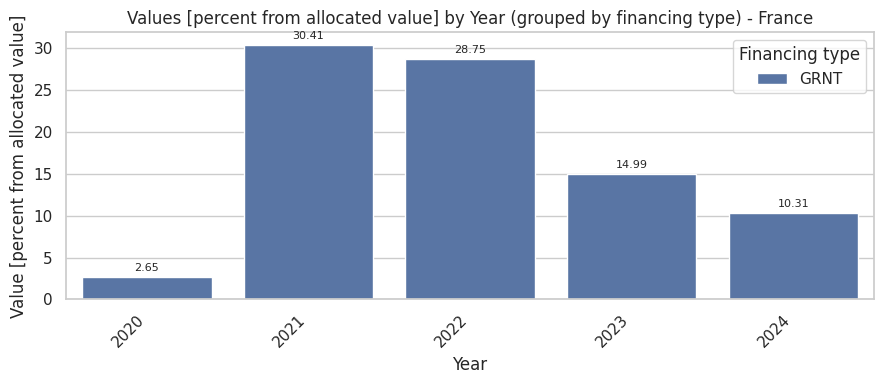

In [16]:
# Order the x-axis nicely
order = sorted(gr["TIME_PERIOD"].unique())
gr["TIME_PERIOD"] = pd.Categorical(gr["TIME_PERIOD"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=gr,
    x="TIME_PERIOD", y="OBS_VALUE",
    hue="fin_typ", dodge=True, errorbar=None, ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Value [percent from allocated value]")
ax.set_title("Values [percent from allocated value] by Year (grouped by financing type) - France")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Financing type", ncols=1, frameon=True)

# Annotate each bar
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:,.2f}",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

# Comparison with other countries




## Total amount (millions EUR)

We will consider the sum (millions EUR).

In [17]:
gr = df.loc[(df.unit=="MIO_EUR") &\
(df.fin_typ!="TOTAL") &\
(df.na_item=="TOTAL")].groupby(["geo"])["OBS_VALUE"].sum().reset_index()

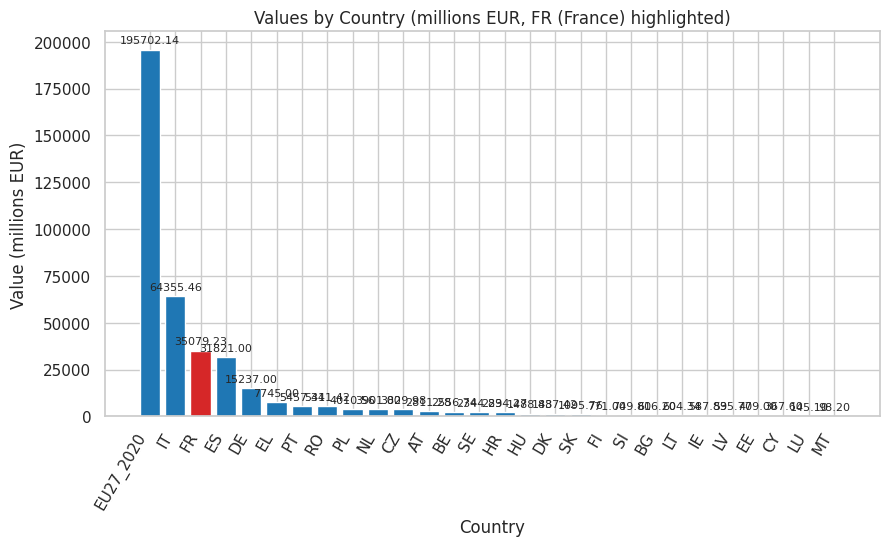

In [18]:
ddf = gr.copy()  # your dataframe with columns: "geo", "OBS_VALUE"

# Optional: sort by value (remove this block if you want original order)
ddf = ddf.sort_values("OBS_VALUE", ascending=False).reset_index(drop=True)

# Colors: FR -> red, others -> blue
ddf["color"] = np.where(ddf["geo"].eq("FR"), "#d62728", "#1f77b4")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ddf["geo"], ddf["OBS_VALUE"], color=ddf["color"])

ax.set_xlabel("Country")
ax.set_ylabel("Value (millions EUR)")
ax.set_title("Values by Country (millions EUR, FR (France) highlighted)")
plt.xticks(rotation=60, ha="right")

# Annotate bars
for x, y in zip(ddf["geo"], ddf["OBS_VALUE"]):
    ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=8)


## Total amount as percent from GDP

We will consider the average percent from GDP, since for each country we have a distribution / year.

In [19]:
gr = df.loc[(df.unit=="PC_GDP") &\
(df.fin_typ!="TOTAL") &\
(df.na_item=="TOTAL")].groupby(["geo"])["OBS_VALUE"].mean().reset_index()

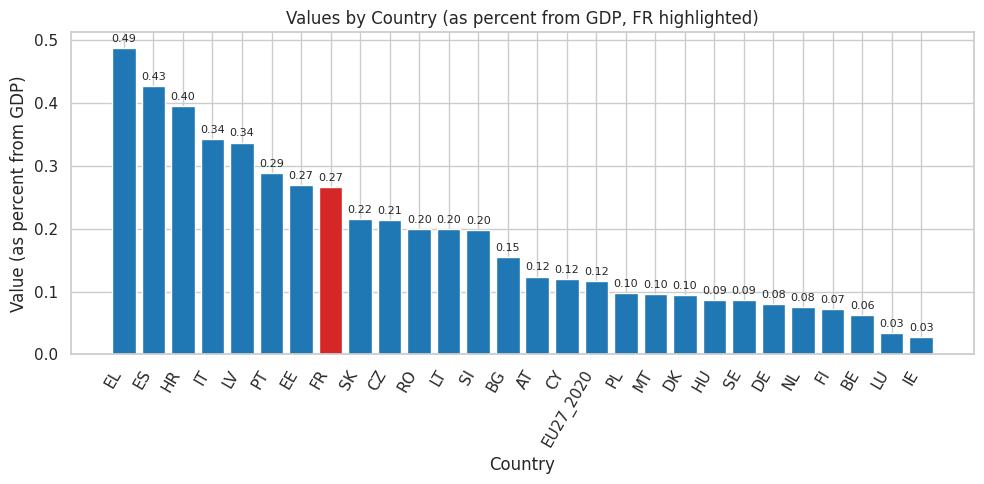

In [20]:
ddf = gr.copy()  # your dataframe with columns: "geo", "OBS_VALUE"

# Optional: sort by value (remove this block if you want original order)
ddf = ddf.sort_values("OBS_VALUE", ascending=False).reset_index(drop=True)

# Colors: FR  -> red, others -> blue
ddf["color"] = np.where(ddf["geo"].eq("FR"), "#d62728", "#1f77b4")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ddf["geo"], ddf["OBS_VALUE"], color=ddf["color"])

ax.set_xlabel("Country")
ax.set_ylabel("Value (as percent from GDP)")
ax.set_title("Values by Country (as percent from GDP, FR highlighted)")
plt.xticks(rotation=60, ha="right")

# Annotate bars
for x, y in zip(ddf["geo"], ddf["OBS_VALUE"]):
    ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Total amount as percent from allocated

We will consider the average percent from allocated, since for each country we have a distribution / year.

In [21]:
gr = df.loc[(df.unit=="PC_ALLOC") &\
(df.fin_typ!="TOTAL") &\
(df.na_item=="TOTAL")].groupby(["geo"])["OBS_VALUE"].mean().reset_index()

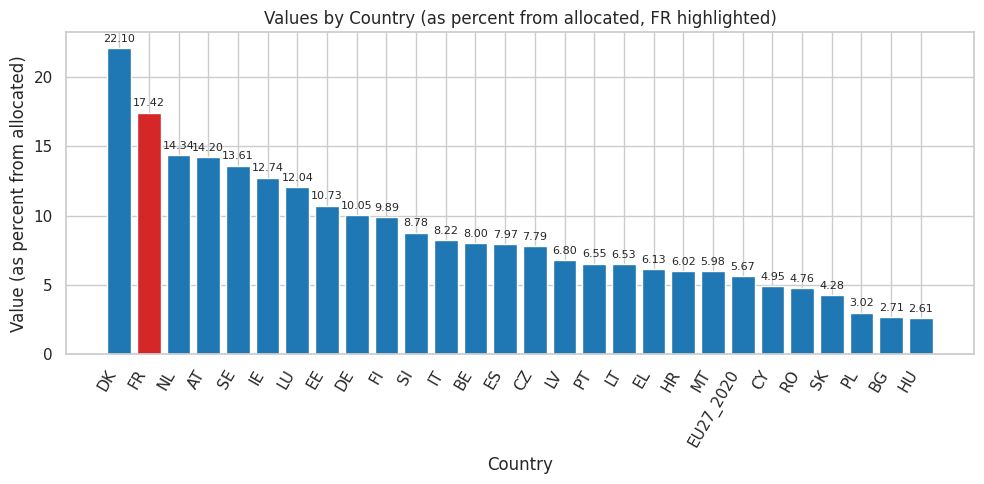

In [22]:
ddf = gr.copy()  # your dataframe with columns: "geo", "OBS_VALUE"

# Optional: sort by value (remove this block if you want original order)
ddf = ddf.sort_values("OBS_VALUE", ascending=False).reset_index(drop=True)

# Colors: FR -> red, others -> blue
ddf["color"] = np.where(ddf["geo"].eq("FR"), "#d62728", "#1f77b4")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ddf["geo"], ddf["OBS_VALUE"], color=ddf["color"])

ax.set_xlabel("Country")
ax.set_ylabel("Value (as percent from allocated)")
ax.set_title("Values by Country (as percent from allocated, FR highlighted)")
plt.xticks(rotation=60, ha="right")

# Annotate bars
for x, y in zip(ddf["geo"], ddf["OBS_VALUE"]):
    ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()